# Imports and data

In [15]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
import matplotlib.pyplot as plt
from utils.publication_lags import apply_fred_md_publication_lag
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

repo_root = os.path.abspath('..')

# Bianchi period:
start_date = '1971-08-31'
# end_date = '2018-12-31'
end_date = '2025-06-30' # kr and gsw end date

maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months

# adjust fred_md start_date by 6 months to fetch enough data for shifting
fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=fred_md_start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# If wanted, apply per-series publication lag to latest-snapshot macro data
# from utils.publication_lags import apply_fred_md_publication_lag
# fred_md = apply_fred_md_publication_lag(fred_md_raw)  
# For results in paper, we naively shift all FRED-MD series by 1 month
# to reflect publication lag:
fred_md = fred_md_raw.shift(1)

# Drop TWEXAFEGSMTHx and ACOGNO as they start late
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
# Finally, revert fred_md to start_date, after transformations and lag adjustments
fred_md = fred_md[start_date:end_date]

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
# For now, forward fill X
X = X.ffill()

groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


# Expanding window estimation

Running pcr_forward...


Model: pcr_forward
 R2_OOS = 0.0643
 Significance: 0.006



<Axes: xlabel='date'>

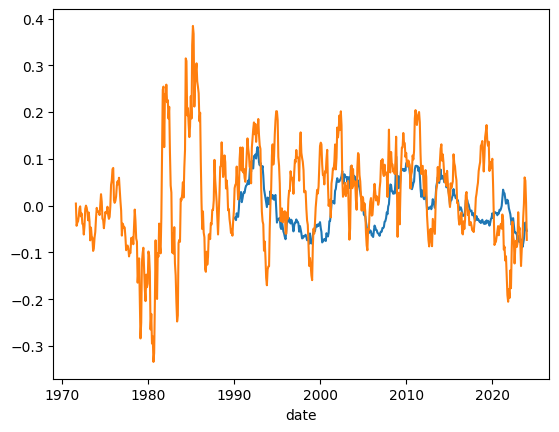

In [5]:
from models.base import *
from models.classical import *
from models.gbt import *
from models.linear import *
from models.tree import *
from tqdm import tqdm

OOS_start = pd.Timestamp('1990-01-31')

coefs = []

def record_coef(coef):
    coefs.append(np.abs(coef).copy())  # store absolute value

benchmark_models = {
    # 'RW': RandomWalkModel(),
    # 'Mean': HistoricalMeanModel(),
    # 'CP': CochranePiazzesiModel(),
    # 'LN': LudvigsonNgModel(),
    # 'LN_BH': LudvigsonNgBauerHamiltonSpec(),
    # 'Linear': LinearModel() # OLS on forward rates
}

macro_models = {
    # 'MacroExtraTrees': ExtraTreesModel(features={
    #     'forward': {'method': 'raw'},
    # }),
    # 'PCAPlusN': PCABaselineModelPlusN(components=3, series='forward', n_extra=1),
    # 'PCAMacroGroups': PCABaselineModelMacroGroups(components=3, series='forward', lasso=True, alpha=0.01, macro_pcs=0),
    # 'PCAMacroGroupsHYPERGRID': PCABaselineModelMacroGroupsHYPERGRID(components=3, series='forward', lasso=True)
    # 'PCAMacroGroupsNoLasso': PCABaselineModelMacroGroups(components=3, series='forward', lasso=False, alpha=0.01),
    # 'GroupPCARF': GroupPCARandomForest(components=3, series='forward', macro_pcs=1),
    # 'GroupPCARF2': GroupPCARandomForest(components=3, series='forward', macro_pcs=2),
    # 'GroupLasso': GroupLassoModel(groups=groups),
}

forward_only_models = {
    # 'lasso_forward': LassoModel(series='forward', alphas=[0.1, 0.01, 0.001]),
    # 'ridge_forward': RidgeModel(series='forward', alphas=[0.1]),
    'pcr_forward': PCABaselineModel(components=3, series='forward'),
    # 'pcr_extra_trees_forward': ExtraTreesForwardModel(scale=True, use_pca=True, n_components=5, tune_every=60),
    # 'pcr_random_forest_forward': RandomForestForwardModel(scale=True, use_pca=True, n_components=5, tune_every=60),
}

tree_models = {
    # "Tree_RF": FwdFredTreeEnsemble1D(estimator="rf"),
    # "Tree_ET": FwdFredTreeEnsemble1D(estimator="ef"),
    # "Tree_XGB": FwdFredTreeEnsemble1D(estimator="xgb"),
    # "Tree_LGBM": FwdFredTreeEnsemble1D(estimator="lgbm"),

    # # Forward-only variants:
    # "Tree_RF_FwdOnly": FwdFredTreeEnsemble1D(estimator="rf", include_fred=False),
    # "Tree_ET_FwdOnly": FwdFredTreeEnsemble1D(estimator="ef", include_fred=False),
    # "Tree_XGB_FwdOnly": FwdFredTreeEnsemble1D(estimator="xgb", include_fred=False),
    # "Tree_LGBM_FwdOnly": FwdFredTreeEnsemble1D(estimator="lgbm", include_fred=False)
}

all_models = {**benchmark_models, **macro_models, **forward_only_models, **tree_models}

y = xr['120'].values # 10-year overlapping excess returns
# y = monthly_xr['24'].values # 1-month excess returns
GAP = 0
for name, model in all_models.items():
    print(f"Running {name}...")
    y_forecast_bianchi = wu.expanding_window(
        model, X, y, dates, OOS_start, 
        gap=GAP,         # gap = 11 for annual yields
        refit_freq=1,     # Refit every month
        realtime=False
    )

    r2 = wu.oos_r2(y, y_forecast_bianchi, gap=GAP)
    print(f"Model: {name}\n R2_OOS = {r2:.4f}\n Significance: {bu.RSZ_Signif(y, y_forecast_bianchi, gap=GAP):.3f}\n")  

sns.lineplot(y=y_forecast_bianchi, x=yields.index)
sns.lineplot(y=y, x=yields.index)

In [11]:
MATURITIES = ['24','36','48','60','84','120']
# MATURITIES = ['120']
GAP = 0
for name, model in all_models.items():
    for maturity in tqdm(MATURITIES, desc=f"Evaluating {name} across maturities", position=0):
        y = xr[maturity].values

        y_forecast_bianchi = wu.expanding_window(
            model, X, y, dates, OOS_start, 
            gap=GAP,         # gap = 11 for annual nonoverlapping yields
            refit_freq=1,     # Refit every month
        ) 

        r2 = wu.oos_r2(y, y_forecast_bianchi, gap=GAP)
        print(f"Model: {name}\tMaturity {maturity}:\n R2_OOS = {r2:.4f}\n Significance: {bu.RSZ_Signif(y, y_forecast_bianchi, gap=GAP):.3f}\n")   

Evaluating pcr_forward across maturities:  17%|█▋        | 1/6 [00:00<00:04,  1.08it/s]

Model: pcr_forward	Maturity 24:
 R2_OOS = -0.1894
 Significance: 0.192



Evaluating pcr_forward across maturities:  33%|███▎      | 2/6 [00:01<00:03,  1.08it/s]

Model: pcr_forward	Maturity 36:
 R2_OOS = -0.1208
 Significance: 0.160



Evaluating pcr_forward across maturities:  50%|█████     | 3/6 [00:02<00:02,  1.09it/s]

...

Model: pcr_forward	Maturity 60:
 R2_OOS = -0.0223
 Significance: 0.052



Evaluating pcr_forward across maturities:  83%|████████▎ | 5/6 [00:05<00:01,  1.15s/it]

Model: pcr_forward	Maturity 84:
 R2_OOS = 0.0110
 Significance: 0.026



Evaluating pcr_forward across maturities: 100%|██████████| 6/6 [00:06<00:00,  1.07s/it]

Model: pcr_forward	Maturity 120:
 R2_OOS = 0.0819
 Significance: 0.007



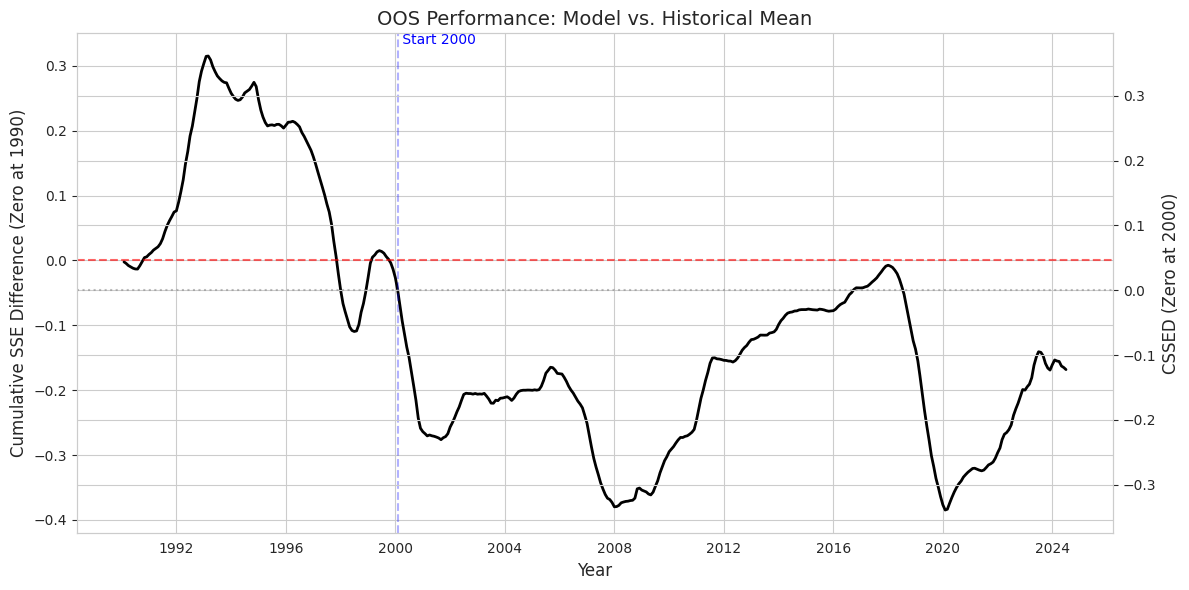

In [102]:
# After running wu.expanding_window:
secondary_zero = pd.Timestamp('2000-01-31')
bu.plot_cssed(y, y_forecast_bianchi, dates, OOS_start, secondary_start=secondary_zero, model_name='Model')

<Axes: xlabel='date'>

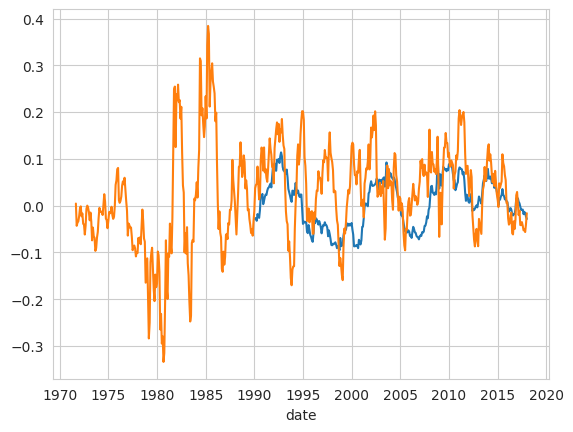

In [34]:
sns.lineplot(y=y_forecast_bianchi, x=yields.index)
sns.lineplot(y=y, x=yields.index)

# Neural networks with multiple outputs:

In [5]:
from models.macro_forward_ann import MacroForwardANNWrapper
from models.group_ensemble_ann import GroupEnsembleANNWrapper
from models.ann_vector_validation import PyTorchMLPWrapper

import importlib
import sys
importlib.reload(sys.modules['models.group_ensemble_ann'])
importlib.reload(sys.modules['models.macro_forward_ann'])
importlib.reload(sys.modules['models.ann_vector_validation'])


OOS_start = pd.Timestamp('1990-01-31')

# maturities = ['24', '36', '48', '60', '72', '84', '96', '108', '120']
# maturities = ['24', '36', '48', '60', '84', '120']
maturities = ['120']

# y_all = xr[maturities].values
y_all = monthly_xr[maturities].values
dates = monthly_xr.index


models_dict = {
    'FwdANN_5_5_5': PyTorchMLPWrapper(archi=(5,5,5), lr=0.001, epochs=1000, tune_every=60, patience=50, param_grid={'penalty':  [1e-4, 1e-3, 1e-2, 0.1]},
                                       seed=2, use_pca=False, n_components=None, y_center=True, activation='tanh') # y_center = True for standardization with subtracting mean
    # 'MacroANN_1_3': MacroForwardANNWrapper(archi_forward=(3, 3,), archi_macro=(8,), lr=0.001, epochs=1000, tune_every=60,
    #                             patience=50, param_grid={'penalty': [1e-4, 1e-3, 1e-2, 0.1, 1.0, 2.5, 5.0], 'dropout_rate': [0.0, 0.1, 0.3]}, 
    #                             seed=616, y_center=True, activation='tanh'),
    # 'GroupEnsemble_1_3': GroupEnsembleANNWrapper(archi_forward=(), archi_macro=(2,1), lr=0.001, epochs=1000, tune_every=60,
    #                             patience=50, param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]}, seed=66,
    #                             activation='tanh')
}
GAP = 11

for name, model in models_dict.items():
    y_forecast = wu.expanding_window(model, X, y_all, dates, OOS_start, gap=GAP, refit_freq=1)
    r2s = wu.oos_r2(y_all, y_forecast, gap=GAP)
    print(f"\n--- OOS R² Summary for {name} ---")
    for mat, r2 in zip(maturities, r2s):
        print(f"  {mat}m: {r2:.4f}")


--- OOS R² Summary for FwdANN_1_31 ---
  120m: -0.0078


In [ ]:
import itertools

# Grid search for MacroForwardANN over monthly excess returns
eval_maturities = ['24', '36', '48', '60', '84', '120']
y_eval = monthly_xr[eval_maturities].values

# Define base architecture blocks
fwd_archs = [
    (3,), (3, 3), (3, 3, 3),
    (5,), (5, 5), (5, 5, 5),
    (7,), (7, 7), (7, 7, 7)
]
macro_archs = [(8,), (16,), (32,)]
learning_rates = [0.001, 0.005]

# Generate combinations
configs = [
    {'archi_forward': fwd, 'archi_macro': mac, 'lr': lr}
    for fwd, mac, lr in itertools.product(fwd_archs, macro_archs, learning_rates)
]

fixed_seed = 42
gap = 0
log_file = "macroann_grid_search_log_vector_returns.txt"

# Write a startup header to the file
with open(log_file, "a") as f:
    f.write(f"\n\n--- Starting MacroForwardANN search over {len(configs)} configurations ---\n")

print(f"Starting MacroForwardANN search over {len(configs)} configurations for monthly returns...")
print(f"Results will be appended to: {log_file}")

for i, cfg in enumerate(configs):
    config_msg = f"[{i+1}/{len(configs)}] Testing config: archi_fwd={cfg['archi_forward']}, archi_macro={cfg['archi_macro']}, lr={cfg['lr']}"
    print(f"\n{config_msg}")
    
    with open(log_file, "a") as f:
        f.write(f"{config_msg}\n")
    
    model = MacroForwardANNWrapper(
        archi_forward=cfg['archi_forward'], 
        archi_macro=cfg['archi_macro'], 
        lr=cfg['lr'], 
        epochs=1000, 
        tune_every=60,
        patience=60, # slightly lower patience to fail faster during search
        param_grid={'penalty': [1e-4, 1e-3, 0.01, 0.1, 1.0], 'dropout_rate': [0.0, 0.1]}, 
        seed=fixed_seed, 
        y_center=True, 
        activation='tanh'
    )
    
    # Run the expanding window estimation (progress=False keeps the notebook output clean)
    y_pred = wu.expanding_window(model, X, y_eval, dates, OOS_start, gap=gap, refit_freq=1, progress=False)
    
    # Calculate and output out-of-sample R-squared
    r2s = wu.oos_r2(y_eval, y_pred, gap=gap)
    
    for mat, r2 in zip(eval_maturities, r2s):
        res_msg = f"  -> R2_OOS ({mat}m): {r2:.4f}"
        print(res_msg)
        with open(log_file, "a") as f:
            f.write(f"{res_msg}\n")

Starting MacroForwardANN search over 54 configurations for monthly returns...
Results will be appended to: macroann_grid_search_log_vector_returns.txt

[1/54] Testing config: archi_fwd=(3,), archi_macro=(8,), lr=0.001
  -> R2_OOS (24m): -0.8995
  -> R2_OOS (36m): -0.0682
  -> R2_OOS (48m): -0.1042
  -> R2_OOS (60m): -0.0360
  -> R2_OOS (84m): -0.1233
  -> R2_OOS (120m): -0.0598

[2/54] Testing config: archi_fwd=(3,), archi_macro=(8,), lr=0.005
  -> R2_OOS (24m): -0.1317
  -> R2_OOS (36m): -0.0559
  -> R2_OOS (48m): -0.0420
  -> R2_OOS (60m): 0.0062
  -> R2_OOS (84m): -0.0101
  -> R2_OOS (120m): -0.0249

[3/54] Testing config: archi_fwd=(3,), archi_macro=(16,), lr=0.001
  -> R2_OOS (24m): -0.0347
  -> R2_OOS (36m): 0.0070
  -> R2_OOS (48m): -0.0226
  -> R2_OOS (60m): -0.0083
  -> R2_OOS (84m): 0.0067
  -> R2_OOS (120m): 0.0125

[4/54] Testing config: archi_fwd=(3,), archi_macro=(16,), lr=0.005
  -> R2_OOS (24m): -0.0806
  -> R2_OOS (36m): -0.0818
  -> R2_OOS (48m): -0.0585
  -> R2_OOS (

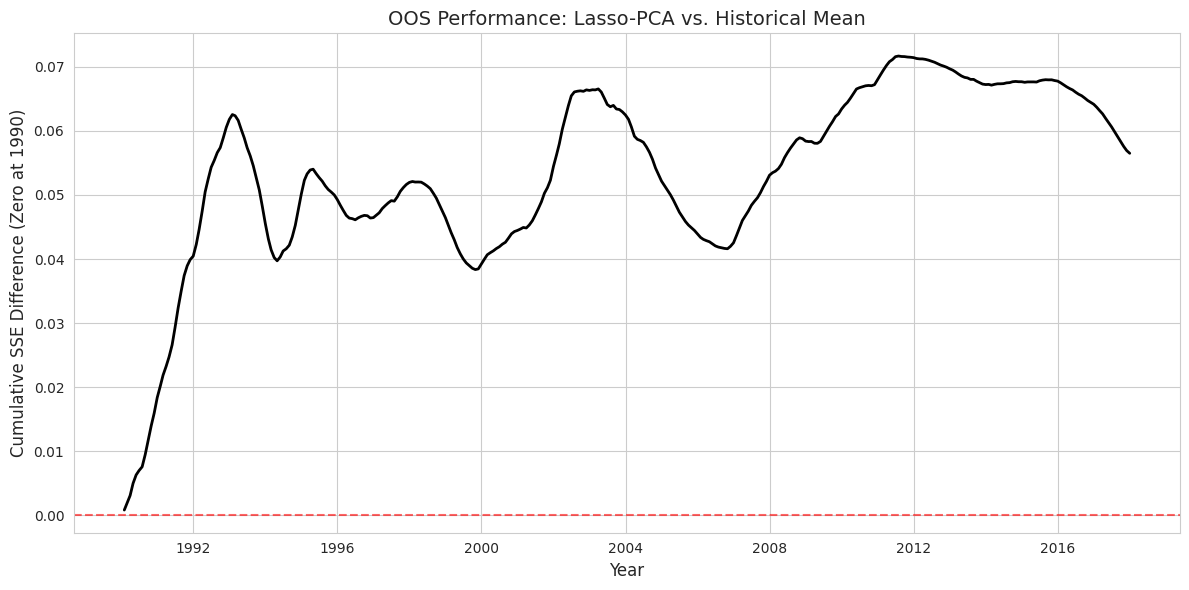

In [88]:
# After running wu.expanding_window:
bu.plot_cssed(y_all[:, -4], y_forecast[:, -4], dates, OOS_start, secondary_start=None, model_name='Lasso-PCA', gap=GAP)

In [9]:
from tqdm import tqdm
MATURITIES = ['24', '36', '48', '60', '84', '120']

def train_models(X, y_all, dates, OOS_start, n_models=100):
    """
    Function 1: Orchestrates running n_models with different seeds.
    """
    all_forecasts = []
    all_val_losses = []

    n_outputs = y_all.shape[1] if y_all.ndim > 1 else 1

    for seed in tqdm(range(n_models)):
        # Instantiate your single-seed wrapper
        # FwdANN:
        model = PyTorchMLPWrapper(archi=(5,5,5), lr=0.001, epochs=1000, tune_every=60, patience=50, param_grid={'penalty':  [1e-4, 1e-3, 1e-2, 0.1]}, 
                          seed=seed, use_pca=False, n_components=None, y_center=True, activation='tanh') # y_center = True for standardization with subtracting mean
        # MacroForwardANN:
        # model = MacroForwardANNWrapper(archi_forward=(7, 7, 7), archi_macro=(32,), lr=0.001, epochs=1000, tune_every=60,
        #     patience=50, param_grid={'penalty': [1e-4, 1e-3, 0.01, 0.1, 1.0], 'dropout_rate': [0.0, 0.1]}, seed=seed, y_center=True)
        # GroupEnsembleANN:
        # model = GroupEnsembleANNWrapper(archi_forward=(3,3), archi_macro=(2, 1), lr=0.001, epochs=1000, tune_every=60,
        #                         patience=50, param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]}, seed=seed,
        #                         activation='tanh')

        # Modified to store per-output validation losses
        val_losses_for_seed = np.full((len(dates), n_outputs), np.nan)

        # Save callback allows us to grab the val_loss tracked inside the model at each expanding window step
        def save_cb(model, refit_i, t_index, date_value, **kwargs):
            if hasattr(model, 'val_loss_') and model.val_loss_ is not None:
                val_losses_for_seed[t_index] = model.val_loss_

        y_forecast = wu.expanding_window(
            model, X, y_all, dates, OOS_start,
            gap=GAP, refit_freq=1,
            save_callback=save_cb,
            progress=False # Turn off individual tqdm so the notebook isn't flooded
        )

        all_forecasts.append(y_forecast)
        all_val_losses.append(val_losses_for_seed)

    return all_forecasts, all_val_losses

def format_ensemble_arrays(all_forecasts, all_val_losses):
    """
    Function 2: Constructs the structured arrays.
    Returns:
      forecasts_array: Shape (Date x Seeds x Outputs)
      val_losses_array: Shape (Date x Seeds x Outputs)
    """
    # np.stack connects the lists along a new dimension for the seed (axis=1)
    forecasts_array = np.stack(all_forecasts, axis=1)
    val_losses_array = np.stack(all_val_losses, axis=1) # Now 3D array

    return forecasts_array, val_losses_array

def _nanmean_with_counts(arr, axis):
    """NaN-safe mean and valid-count helper for selection statistics."""
    valid_counts = np.sum(~np.isnan(arr), axis=axis)
    sums = np.nansum(arr, axis=axis)
    means = np.divide(
        sums,
        valid_counts,
        out=np.full(np.shape(sums), np.nan, dtype=float),
        where=valid_counts > 0,
    )
    return means, valid_counts

def compute_top_k_ensemble(
    forecasts_array,
    val_losses_array,
    k,
    selection_mode='per_maturity',
    selection_metric='val_loss',
    y_true=None,
    lookback=120,
    min_history=24,
    realization_lag=0,
):
    """
    Function 3: Calculates top-K ensemble predictions.

    selection_mode:
      - 'per_maturity': choose top-K separately for each output node
      - 'total': choose one top-K set for all outputs

    selection_metric:
      - 'val_loss': rank seeds by in-fit validation loss (original behavior)
      - 'trailing_oos': rank seeds by trailing realized OOS MSE,
                        using only outcomes available at forecast time.
                        If there is insufficient realized history, falls back to val_loss.
    """
    if selection_mode not in {'per_maturity', 'total'}:
        raise ValueError("selection_mode must be either 'per_maturity' or 'total'")
    if selection_metric not in {'val_loss', 'trailing_oos'}:
        raise ValueError("selection_metric must be either 'val_loss' or 'trailing_oos'")

    T, n_seeds, n_outputs = forecasts_array.shape
    ensemble_forecast = np.full((T, n_outputs), np.nan)

    if selection_metric == 'trailing_oos':
        if y_true is None:
            raise ValueError("y_true must be provided when selection_metric='trailing_oos'")
        y_true = np.asarray(y_true)
        if y_true.ndim == 1:
            y_true = y_true.reshape(-1, 1)
        if y_true.shape != (T, n_outputs):
            raise ValueError(
                f"y_true must have shape {(T, n_outputs)}; got {y_true.shape}"
            )

    def _select_total_from_val_losses(t):
        seed_valid_counts = np.sum(~np.isnan(val_losses_array[t]), axis=1)
        seed_loss_sums = np.nansum(val_losses_array[t], axis=1)
        seed_losses = np.divide(
            seed_loss_sums,
            seed_valid_counts,
            out=np.full(n_seeds, np.nan, dtype=float),
            where=seed_valid_counts > 0,
        )
        valid_idx = np.where(~np.isnan(seed_losses))[0]
        return seed_losses, valid_idx

    def _select_per_maturity_from_val_losses(t, m):
        v_losses = val_losses_array[t, :, m]
        valid_idx = np.where(~np.isnan(v_losses))[0]
        return v_losses, valid_idx

    for t in range(T):
        if selection_mode == 'total':
            use_val_fallback = False

            if selection_metric == 'trailing_oos':
                hist_end = t - realization_lag
                hist_start = max(0, hist_end - lookback)

                if hist_end > hist_start:
                    trailing_err = (
                        forecasts_array[hist_start:hist_end] - y_true[hist_start:hist_end, None, :]
                    ) ** 2
                    seed_losses, seed_valid_counts = _nanmean_with_counts(
                        trailing_err, axis=(0, 2)
                    )
                    valid_idx = np.where(
                        (~np.isnan(seed_losses)) & (seed_valid_counts >= min_history)
                    )[0]
                else:
                    valid_idx = np.array([], dtype=int)

                if len(valid_idx) == 0:
                    use_val_fallback = True
            else:
                use_val_fallback = True

            if use_val_fallback:
                seed_losses, valid_idx = _select_total_from_val_losses(t)

            if len(valid_idx) == 0:
                continue

            actual_k = min(k, len(valid_idx))
            sorted_valid_idx = valid_idx[np.argsort(seed_losses[valid_idx])]
            top_k_indices = sorted_valid_idx[:actual_k]

            selected_preds = forecasts_array[t, top_k_indices, :]
            pred_means, _ = _nanmean_with_counts(selected_preds, axis=0)
            ensemble_forecast[t] = pred_means

        else:
            # Per-maturity mode: possibly different top-K seeds for each maturity
            trailing_seed_losses = None
            trailing_seed_counts = None

            if selection_metric == 'trailing_oos':
                hist_end = t - realization_lag
                hist_start = max(0, hist_end - lookback)
                if hist_end > hist_start:
                    trailing_err = (
                        forecasts_array[hist_start:hist_end] - y_true[hist_start:hist_end, None, :]
                    ) ** 2
                    trailing_seed_losses, trailing_seed_counts = _nanmean_with_counts(
                        trailing_err, axis=0
                    )

            for m in range(n_outputs):
                use_val_fallback = False

                if selection_metric == 'trailing_oos' and trailing_seed_losses is not None:
                    v_losses = trailing_seed_losses[:, m]
                    counts = trailing_seed_counts[:, m]
                    valid_idx = np.where((~np.isnan(v_losses)) & (counts >= min_history))[0]
                    if len(valid_idx) == 0:
                        use_val_fallback = True
                else:
                    use_val_fallback = True

                if use_val_fallback:
                    v_losses, valid_idx = _select_per_maturity_from_val_losses(t, m)

                if len(valid_idx) == 0:
                    continue

                actual_k = min(k, len(valid_idx))
                sorted_valid_idx = valid_idx[np.argsort(v_losses[valid_idx])]
                top_k_indices = sorted_valid_idx[:actual_k]

                selected_preds_m = forecasts_array[t, top_k_indices, m]
                valid_preds_m = selected_preds_m[~np.isnan(selected_preds_m)]
                if len(valid_preds_m) == 0:
                    continue
                ensemble_forecast[t, m] = np.mean(valid_preds_m)

    return ensemble_forecast

y_all = xr[MATURITIES].values
dates = xr.index

# Execute the workflow you asked for (keeps original behavior):
all_preds, all_losses = train_models(X, y_all, dates, OOS_start, n_models=100)
forecasts_arr, losses_arr = format_ensemble_arrays(all_preds, all_losses)
final_y_forecast = compute_top_k_ensemble(
    forecasts_arr,
    losses_arr,
    k=10,
    selection_mode='per_maturity',
)

r2s = wu.oos_r2(y_all, final_y_forecast, benchmark='hist_mean', gap=GAP)
print(f"\n--- OOS R² Summary for Top-K Ensemble ---")
for mat, r2 in zip(MATURITIES, r2s):
    print(f"  {mat}m: {r2:.4f}")

# Optional gap-aware selector based on trailing realized OOS performance:
final_y_forecast = compute_top_k_ensemble(
    forecasts_arr,
    losses_arr,
    k=10,
    selection_mode='per_maturity',
    selection_metric='trailing_oos',
    y_true=y_all,
    lookback=120,
    min_history=24,
    realization_lag=GAP,
)

r2s = wu.oos_r2(y_all, final_y_forecast, benchmark='hist_mean', gap=GAP)
print(f"\n--- OOS R² Summary for Top-K Ensemble ---")
for mat, r2 in zip(MATURITIES, r2s):
    print(f"  {mat}m: {r2:.4f}")

100%|██████████| 100/100 [34:46<00:00, 20.86s/it]


--- OOS R² Summary for Top-K Ensemble ---
  24m: -0.1999
  36m: -0.1898
  48m: -0.1145
  60m: -0.1258
  84m: -0.0733
  120m: 0.0161

--- OOS R² Summary for Top-K Ensemble ---
  24m: -0.0142
  36m: 0.0030
  48m: 0.0042
  60m: 0.0441
  84m: 0.0803
  120m: 0.0764


In [ ]:
r2s = wu.oos_r2(y_all, final_y_forecast, benchmark='hist_mean', gap=GAP)

<Axes: xlabel='date'>

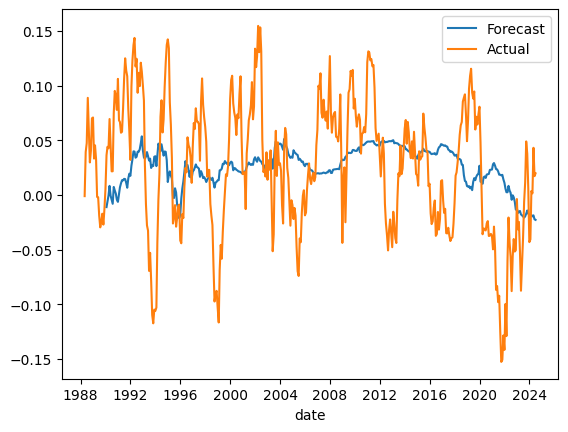

In [10]:
sns.lineplot(y=final_y_forecast[:, -2], x=yields.index, label='Forecast')
sns.lineplot(y=y_all[:, -2][200:], x=yields[200:].index, label='Actual')

# Load artifact checkpoints and alter ensemble

In [8]:
y_all_forecast = np.load('/home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10/20260430_032808/forecasts_arr.npy') # 100 models
losses_all = np.load('/home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10/20260430_032808/losses_arr.npy') # 100 models
topk_all_val_loss = np.load('/home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10/20260430_032808/topk_indices_val_loss.npy') # top-10 ensemble based on val_loss
topk_trailing_oos = np.load('/home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10/20260430_032808/topk_indices_trailing_oos.npy') # top-10 ensemble based on trailing OOS

In [ ]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
from utils.orchestrator_utils import compute_top_k_ensemble
from utils.window_utils import oos_r2
import utils.base_utils as bu


def recalculate_ensemble_for_k(run_dir: str, new_k: int, y_true: np.ndarray, dates=None):
    """
    Recalculates the top-k ensembles ('val_loss' and 'trailing_oos') for an existing
    experiment directory utilizing the saved Numpy arrays.
    """
    run_path = Path(run_dir)

    forecasts_arr = np.load(run_path / 'forecasts_arr.npy')
    losses_arr = np.load(run_path / 'losses_arr.npy')

    with open(run_path / 'run_config.json', 'r') as f:
        cfg = json.load(f)

    n_outputs = forecasts_arr.shape[2]
    maturities = cfg.get("maturities", range(n_outputs))
    benchmark = cfg.get("benchmark", "hist_mean")
    gap = cfg.get("gap", 0)
    selection_mode = cfg.get("ensemble_selection_mode", "per_maturity")

    y_true_arr = np.asarray(y_true)
    if y_true_arr.ndim == 1:
        y_true_arr = y_true_arr.reshape(-1, 1)

    common_len = min(forecasts_arr.shape[0], y_true_arr.shape[0])
    if common_len != forecasts_arr.shape[0] or common_len != y_true_arr.shape[0]:
        print(
            f"Warning: aligning forecasts ({forecasts_arr.shape[0]}) and y_true ({y_true_arr.shape[0]}) "
            f"to common length {common_len}."
        )

    forecasts_eval = forecasts_arr[:common_len]
    losses_eval = losses_arr[:common_len]
    y_true_eval = y_true_arr[:common_len]

    results = {}
    performance = []

    for metric in ["val_loss", "trailing_oos"]:
        ens_forecast, topk_idx = compute_top_k_ensemble(
            forecasts_array=forecasts_eval,
            val_losses_array=losses_eval,
            k=new_k,
            selection_mode=selection_mode,
            selection_metric=metric,
            y_true=y_true_eval,
            lookback=cfg.get("trailing_lookback", 120),
            min_history=cfg.get("trailing_min_history", 24),
            realization_lag=cfg.get("trailing_realization_lag") or gap,
        )

        results[metric] = {
            "forecast": ens_forecast,
            "indices": topk_idx,
        }

        r2s = oos_r2(y_true_eval, ens_forecast, benchmark=benchmark, gap=gap)
        pvals = [bu.RSZ_Signif(y_true_eval[:, i], ens_forecast[:, i], gap=gap) for i in range(n_outputs)]

        for maturity, r2, pval in zip(maturities, r2s.tolist(), pvals):
            performance.append({
                "k_top": new_k,
                "ensemble_method": metric,
                "maturity": maturity,
                "r2_oos": r2,
                "rsz_pval": pval,
            })

    perf_df = pd.DataFrame(performance)
    return results, perf_df

In [ ]:
run_dir_path = "/home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10/20260430_032808"
new_k = 50  # For example, recalculate for top 5

# Ensure we use the correct y_all from the experiment shape.
# It seems y_all currently in the notebook space only has 1 column ('120')
# while the experiment was likely run with all 6 MATURITIES ('24', '36', '48', '60', '84', '120').
import json
with open(f"{run_dir_path}/run_config.json", 'r') as f:
    cfg = json.load(f)
experiment_maturities = cfg.get("maturities", ['24', '36', '48', '60', '84', '120'])
y_true_experiment = xr[experiment_maturities].values

results, perf_df = recalculate_ensemble_for_k(
    run_dir=run_dir_path,
    new_k=new_k,
    y_true=y_true_experiment
)

forecast_len = next(iter(results.values()))["forecast"].shape[0]
common_len = min(len(y_true_experiment), forecast_len)
if common_len != len(y_true_experiment):
    y_true_experiment = y_true_experiment[:common_len]
if common_len != len(dates):
    dates = dates[:common_len]
for metric in results:
    results[metric]["forecast"] = results[metric]["forecast"][:common_len]
    results[metric]["indices"] = results[metric]["indices"][:common_len]

# Display the recalculated performance table
display(perf_df)

ValueError: operands could not be broadcast together with shapes (635,) (629,) 

In [12]:
import pandas as pd

# Mask dates up to 2018-12-31
end_date_mask = dates <= pd.Timestamp('2018-12-31')
y_true_sub = y_true_experiment[end_date_mask]
gap_val = cfg.get("gap", 0)
benchmark_val = cfg.get("benchmark", "hist_mean")

print("--- OOS R² up to 2018-12-31 ---")
for metric in ["val_loss", "trailing_oos"]:
    ens_forecast_sub = results[metric]["forecast"][end_date_mask]
    r2s_sub = wu.oos_r2(y_true_sub, ens_forecast_sub, benchmark=benchmark_val, gap=gap_val)
    
    print(f"\nMethod: {metric}")
    for mat, r2 in zip(experiment_maturities, r2s_sub):
        print(f"  {mat}m: {r2:.4f}")

NameError: name 'y_true_experiment' is not defined